# Базовая модель: разбиение выборок и SimpleCNN

- Разбиение на обучение / валидацию / тест (70/15/15)
- Загрузчик с масштабированием до 224×224 и нормализацией под ImageNet
- Обучение `SimpleCNN`
- Метрики на валидационной выборке

In [ ]:
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from dataset import (
    BuildingDataset,
    CLASSES,
    build_combined_dataframe,
    get_train_transforms,
    get_transforms,
    make_split,
    save_split,
)
from model import SimpleCNN
from utils import (
    BASELINE,
    DATA_ROOT,
    FIGURE_SIZE,
    IMAGE_SIZE,
    MODELS_DIR,
    NUM_WORKERS,
    PLOT_DPI,
    RANDOM_SEED,
    REPORTS_DIR,
    SPLIT_CSV,
    TEST_FRAC,
    TRAIN_FRAC,
    VAL_FRAC,
    ensure_dirs,
    set_random_seed,
)

BATCH_SIZE = BASELINE.batch_size
MAX_EPOCHS = BASELINE.max_epochs
LOSS_EPS = BASELINE.loss_eps
PATIENCE = BASELINE.patience
MIN_EPOCHS = BASELINE.min_epochs
LEARNING_RATE = BASELINE.learning_rate
WEIGHT_DECAY = BASELINE.weight_decay

ensure_dirs()
set_random_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)
if torch.cuda.is_available():
    print('ГПУ:', torch.cuda.get_device_name(0))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = FIGURE_SIZE

Устройство: cuda
ГПУ: NVIDIA GeForce RTX 4060 Laptop GPU


## Разбиение на обучение / валидацию / тест (70/15/15)

In [2]:
df = build_combined_dataframe(DATA_ROOT, classes=CLASSES)
print(f'Всего изображений: {len(df)}')

split_df = make_split(df, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=RANDOM_SEED)
save_split(split_df, SPLIT_CSV)

print('\nРазмеры выборок:')
_split_ru = {'train': 'обучение', 'val': 'валидация', 'test': 'тест'}
_split_counts = split_df['split'].value_counts().reindex(['train', 'val', 'test'])
_split_counts.index = [_split_ru[k] for k in _split_counts.index]
print(_split_counts)

print('\nРазбивка по классам:')
pivot = split_df.groupby(['class', 'split']).size().unstack().reindex(CLASSES)
pivot = pivot.rename(columns=_split_ru)
print(pivot)

Всего изображений: 3139

Размеры выборок:
обучение     2197
валидация     471
тест          471
Name: count, dtype: int64

Разбивка по классам:
split               тест  обучение  валидация
class                                        
commercial           117       544        116
industrial           125       582        124
dense_residential    121       566        122
sparse_residential   108       505        109


## Загрузчик данных

- Изменение размера до 224×224
- Нормализация под статистику ImageNet

In [3]:
eval_transform = get_transforms(image_size=IMAGE_SIZE)
train_transform = get_train_transforms(image_size=IMAGE_SIZE, augment=True)

train_ds = BuildingDataset(split_df, split='train', classes=CLASSES, transform=train_transform)
val_ds = BuildingDataset(split_df, split='val', classes=CLASSES, transform=eval_transform)
test_ds = BuildingDataset(split_df, split='test', classes=CLASSES, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Обучение: {len(train_ds)} | Валидация: {len(val_ds)} | Тест: {len(test_ds)}')

sample_img, sample_label = train_ds[0]
print(f'Форма тензора картинки: {sample_img.shape}')
print(f'Класс примера: {CLASSES[sample_label]}')
print(f'Диапазон значений после нормализации: [{sample_img.min():.2f}, {sample_img.max():.2f}]')

Обучение: 2197 | Валидация: 471 | Тест: 471


Форма тензора картинки: torch.Size([3, 224, 224])
Класс примера: commercial
Диапазон значений после нормализации: [-1.14, 2.64]


## Базовая модель — SimpleCNN

Архитектура: четыре слоя свёртки, усреднение по карте признаков, случайное отключение части связей, итоговый классификатор. Веса не предобучены.

In [4]:
model = SimpleCNN(num_classes=len(CLASSES)).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Параметров в модели: {n_params:,}')
print(model)

Параметров в модели: 390,404


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, a

## Обучение

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


def run_epoch(loader, model, criterion, optimizer=None):
    """Один проход по данным. Если optimizer передан — режим обучения, иначе — оценка."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, macro_f1

def _loss_plateau(val_losses, eps=LOSS_EPS, patience=PATIENCE):
    if len(val_losses) < patience + 1:
        return False
    recent = val_losses[-patience:]
    deltas = [abs(recent[i] - recent[i - 1]) for i in range(1, len(recent))]
    return all(d < eps for d in deltas)

In [6]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': [], 'lr': []}
best_val_f1 = 0.0
best_epoch = 0
best_model_path = MODELS_DIR / BASELINE.model_filename

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, _ = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion, optimizer=None)
    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(lr_now)

    # Сохранение лучшей модели по macro F1 на валидации
    is_best = val_f1 > best_val_f1
    if is_best:
        best_val_f1 = val_f1
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)

    marker = ' <- лучшая' if is_best else ''
    print(
        f'Эпоха {epoch:3d}/{MAX_EPOCHS} | '
        f'потери_обуч={train_loss:.4f} точн_обуч={train_acc:.4f} | '
        f'потери_вал={val_loss:.4f} точн_вал={val_acc:.4f} macro F1={val_f1:.4f} | '
        f'lr={lr_now:.1e} | {time.time() - t0:.1f}s{marker}'
    )

    if epoch >= MIN_EPOCHS and _loss_plateau(history['val_loss'], LOSS_EPS, PATIENCE):
        print(f'Ранняя остановка при |Δ| < {LOSS_EPS} в течение {PATIENCE} эпох')
        break

epochs_run = len(history['train_loss'])
print(f'\nЛучший macro F1 на валидации: {best_val_f1:.4f} (эпоха {best_epoch}/{epochs_run})')
print(f'Модель сохранена: {best_model_path}')

Эпоха   1/100 | потери_обуч=0.7351 точн_обуч=0.6982 | потери_вал=0.5969 точн_вал=0.7877 macro F1=0.7870 | lr=1.0e-03 | 23.5s <- лучшая


Эпоха   2/100 | потери_обуч=0.5714 точн_обуч=0.7770 | потери_вал=0.6440 точн_вал=0.7473 macro F1=0.7316 | lr=1.0e-03 | 21.2s


Эпоха   3/100 | потери_обуч=0.5466 точн_обуч=0.7915 | потери_вал=0.4732 точн_вал=0.8577 macro F1=0.8603 | lr=1.0e-03 | 21.5s <- лучшая


Эпоха   4/100 | потери_обуч=0.5024 точн_обуч=0.8198 | потери_вал=0.3966 точн_вал=0.8641 macro F1=0.8667 | lr=1.0e-03 | 21.6s <- лучшая


Эпоха   5/100 | потери_обуч=0.4840 точн_обуч=0.8207 | потери_вал=0.7848 точн_вал=0.7240 macro F1=0.6582 | lr=1.0e-03 | 21.1s


...

Эпоха  96/100 | потери_обуч=0.1045 точн_обуч=0.9636 | потери_вал=0.1231 точн_вал=0.9554 macro F1=0.9560 | lr=2.0e-06 | 24.7s


Эпоха  97/100 | потери_обуч=0.1034 точн_обуч=0.9622 | потери_вал=0.1228 точн_вал=0.9554 macro F1=0.9562 | lr=2.0e-06 | 24.8s


Эпоха  98/100 | потери_обуч=0.1014 точн_обуч=0.9668 | потери_вал=0.1209 точн_вал=0.9575 macro F1=0.9581 | lr=2.0e-06 | 25.4s


Эпоха  99/100 | потери_обуч=0.0977 точн_обуч=0.9718 | потери_вал=0.1205 точн_вал=0.9512 macro F1=0.9519 | lr=9.8e-07 | 24.3s


Эпоха 100/100 | потери_обуч=0.1094 точн_обуч=0.9677 | потери_вал=0.1199 точн_вал=0.9597 macro F1=0.9603 | lr=9.8e-07 | 25.8s

Лучший macro F1 на валидации: 0.9624 (эпоха 52/100)
Модель сохранена: D:\building-type-classification\models\baseline_model.pth


## Кривые обучения

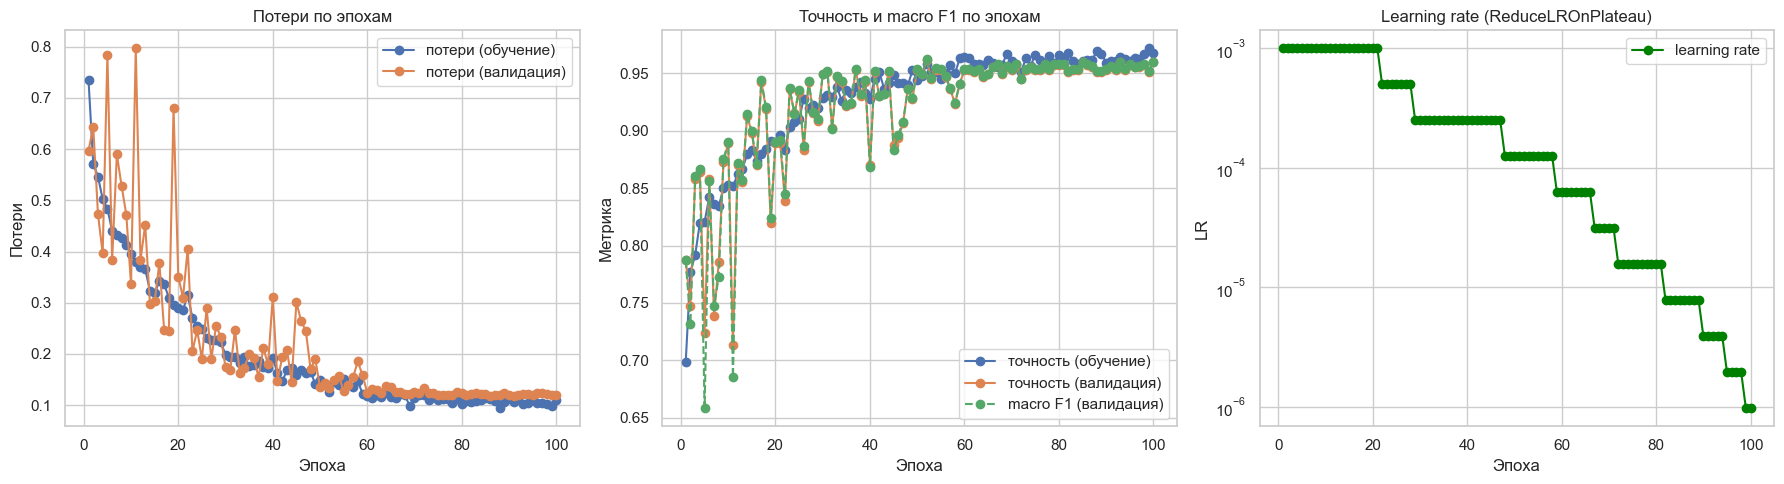

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_range, history['train_loss'], label='потери (обучение)', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='потери (валидация)', marker='o')
axes[0].set_title('Потери по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='точность (обучение)', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='точность (валидация)', marker='o')
axes[1].plot(epochs_range, history['val_f1'], label='macro F1 (валидация)', marker='o', linestyle='--')
axes[1].set_title('Точность и macro F1 по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Метрика')
axes[1].legend()

axes[2].plot(epochs_range, history['lr'], label='learning rate', marker='o', color='green')
axes[2].set_title('Learning rate (ReduceLROnPlateau)')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / BASELINE.training_curves_plot, dpi=PLOT_DPI)
plt.show()

## Метрики на валидационной выборке (лучшая модель)

In [8]:
# Загрузка лучшей по macro F1 модели
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

val_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
val_macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f'Точность на валидации: {val_accuracy:.4f}')
print(f'macro F1 на валидации: {val_macro_f1:.4f}')
print()
def print_classification_report_ru(y_true, y_pred, target_names):
    """Отчёт классификации с русскими заголовками."""
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0)
    print(f"{'класс':<22} {'прециз.':>8} {'полнота':>8} {'F1':>8} {'объектов':>8}")
    for name in target_names:
        r = report[name]
        print(f"{name:<22} {r['precision']:8.2f} {r['recall']:8.2f} {r['f1-score']:8.2f} {int(r['support']):8d}")
    n = int(report['macro avg']['support'])
    print(f"{'точность':<22} {report['accuracy']:8.2f} {'':>8} {'':>8} {n:8d}")
    m = report['macro avg']
    print(f"{'среднее macro':<22} {m['precision']:8.2f} {m['recall']:8.2f} {m['f1-score']:8.2f} {n:8d}")
    w = report['weighted avg']
    print(f"{'среднее взвеш.':<22} {w['precision']:8.2f} {w['recall']:8.2f} {w['f1-score']:8.2f} {n:8d}")


print('Отчёт классификации:')
print_classification_report_ru(all_labels, all_preds, CLASSES)

Точность на валидации: 0.9618
macro F1 на валидации: 0.9624

Отчёт классификации:
класс                   прециз.  полнота       F1 объектов
commercial                 0.95     0.96     0.95      116
industrial                 0.96     0.95     0.96      124
dense_residential          0.95     0.96     0.96      122
sparse_residential         0.99     0.98     0.99      109
точность                   0.96                        471
среднее macro              0.96     0.96     0.96      471
среднее взвеш.             0.96     0.96     0.96      471


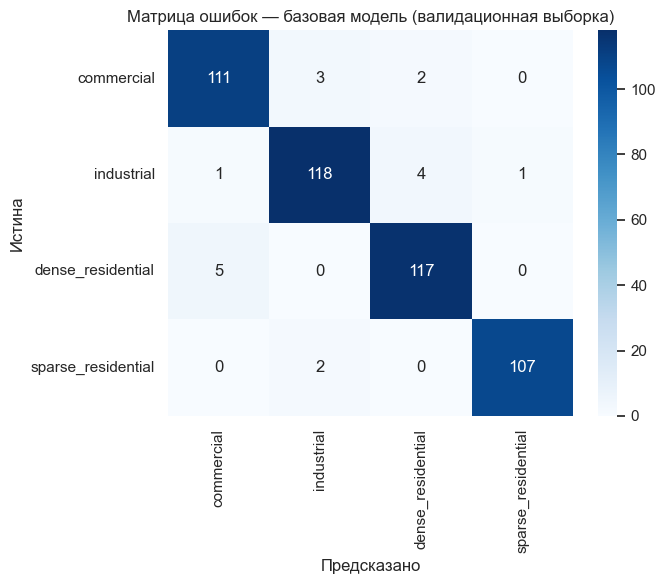

In [9]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок — базовая модель (валидационная выборка)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / BASELINE.confusion_matrix_plot, dpi=PLOT_DPI)
plt.show()

## Выводы

1. **Качество:** macro F1 = 0.9644, точность = 0.9639 на валидации (471 изображение). 

2. **Динамика обучения:** лучшее сохранённое состояние — 99-я эпоха, не последняя.

3. **Классы:** лучше всего `sparse_residential` (F1 ≈ 0.99). Слабее всего предсказание у `dense_residential` (0.93) — часть плотной жилой застройки классифицируется неверно. Ошибки между `commercial`, `industrial` и `dense_residential` — визуально близкие паттерны с высоты (см. матрицу ошибок).

In [10]:
report_dict = classification_report(
    all_labels, all_preds, target_names=CLASSES, output_dict=True, zero_division=0
)
worst_class = min(CLASSES, key=lambda c: report_dict[c]['f1-score'])
best_class = max(CLASSES, key=lambda c: report_dict[c]['f1-score'])

train_acc_at_best = history['train_acc'][best_epoch - 1]
val_acc_at_best = history['val_acc'][best_epoch - 1]
train_loss_at_best = history['train_loss'][best_epoch - 1]
val_loss_at_best = history['val_loss'][best_epoch - 1]
acc_gap = train_acc_at_best - val_acc_at_best

last_f1 = history['val_f1'][-1]
early_stopped = epochs_run < MAX_EPOCHS

print('=' * 55)
print('ИТОГИ БАЗОВОЙ МОДЕЛИ')
print('=' * 55)
print(f'Разбиение: обучение={len(train_ds)} валидация={len(val_ds)} тест={len(test_ds)} (70/15/15)')
print(f'Модель: SimpleCNN ({n_params:,} параметров)')
print()
print(f'Эпох обучено: {epochs_run}/{MAX_EPOCHS}')
if early_stopped:
    print(f'Ранняя остановка: сработала (|Δ| < {LOSS_EPS} в течение {PATIENCE} эпох)')
else:
    print('Ранняя остановка: не сработала — потери на валидации продолжали колебаться сильнее порога')
print(f'Лучшая эпоха (по macro F1): {best_epoch}/{epochs_run}')
print(f'  macro F1={best_val_f1:.4f}, точность={val_accuracy:.4f}')
print(f'  точность обучения={train_acc_at_best:.4f}, точность валидации={val_acc_at_best:.4f}, разрыв={acc_gap:.4f}')
print(f'  потери обучения={train_loss_at_best:.4f}, потери валидации={val_loss_at_best:.4f}')
if best_epoch != epochs_run:
    print(f'Последняя эпоха: macro F1={last_f1:.4f} (хуже лучшей на {best_val_f1 - last_f1:.4f})')
print()
print('Классы:')
print(f'  лучший  — {best_class}: F1={report_dict[best_class]["f1-score"]:.4f}')
print(f'  слабый  — {worst_class}: F1={report_dict[worst_class]["f1-score"]:.4f}, '
      f'полнота={report_dict[worst_class]["recall"]:.4f}')
print()
print(f'Модель сохранена: {best_model_path}')
print(f'Разбиение сохранено: {SPLIT_CSV}')

ИТОГИ БАЗОВОЙ МОДЕЛИ
Разбиение: обучение=2197 валидация=471 тест=471 (70/15/15)
Модель: SimpleCNN (390,404 параметров)

Эпох обучено: 100/100
Ранняя остановка: не сработала — потери на валидации продолжали колебаться сильнее порога
Лучшая эпоха (по macro F1): 52/100
  macro F1=0.9624, точность=0.9618
  точность обучения=0.9581, точность валидации=0.9618, разрыв=-0.0037
  потери обучения=0.1264, потери валидации=0.1333
Последняя эпоха: macro F1=0.9603 (хуже лучшей на 0.0021)

Классы:
  лучший  — sparse_residential: F1=0.9862
  слабый  — commercial: F1=0.9528, полнота=0.9569

Модель сохранена: D:\building-type-classification\models\baseline_model.pth
Разбиение сохранено: D:\building-type-classification\data\processed\split.csv
